<a href="https://colab.research.google.com/github/Adityanarayanjh/Corrosion_Rate/blob/main/mse656_project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Modelling

In [ ]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.3/556.3 kB 6.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
import shap
RND = 42


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_excel("Corrosion_Featured.xlsx")

# Define target variable (the value you want to predict)
y = df["corrosion_rate_mm_per_year"]

# Define features (drop target and any identifiers or non-numeric columns)
X = df.select_dtypes(include=['number']).drop(columns=["corrosion_rate_mm_per_year"], errors='ignore')

# Define random seed
RND = 42

# Split into train-test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RND)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Train Random Forest model
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    random_state=RND,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# Evaluate performance
print("RF R²:", r2_score(y_test, pred_rf))
print("RF MAE:", mean_absolute_error(y_test, pred_rf))



RF R²: 0.9430871441468108
RF MAE: 0.08049718675864652


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


=== Random Forest Evaluation ===
R2 (test): 0.9431
MAE (test): 0.0805
RMSE (test): 0.1225
CV R2 mean (5-fold): 0.9336  (std: 0.0087)
CV MAE mean (5-fold): 0.0821  (std: 0.0039)

Top 15 features by importance:
coating_bin                  0.442553
inv_resistivity              0.198487
is_outlier_rate              0.151874
resistivity_ohm_m            0.140281
relative_resistance_index    0.023261
marine_severity_index        0.002895
%Mn                          0.002306
%C                           0.002235
Cl_OH_ratio                  0.002193
flow_rate_m_s                0.002040
%Cu                          0.001868
relative_humidity_%          0.001851
temp_x_logCl                 0.001780
Ni_Mo_ratio                  0.001776
%Si                          0.001744
dtype: float64

Saved Random Forest model to: rf_corrosion_model.joblib
You can download the model file from the environment or attach it to your submission.


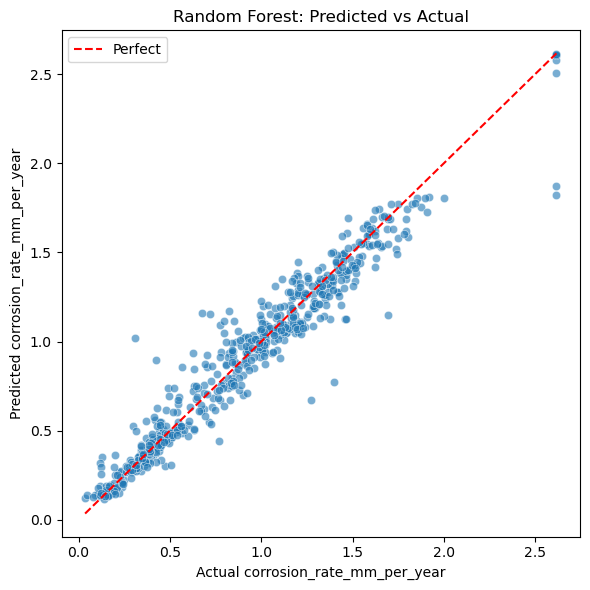

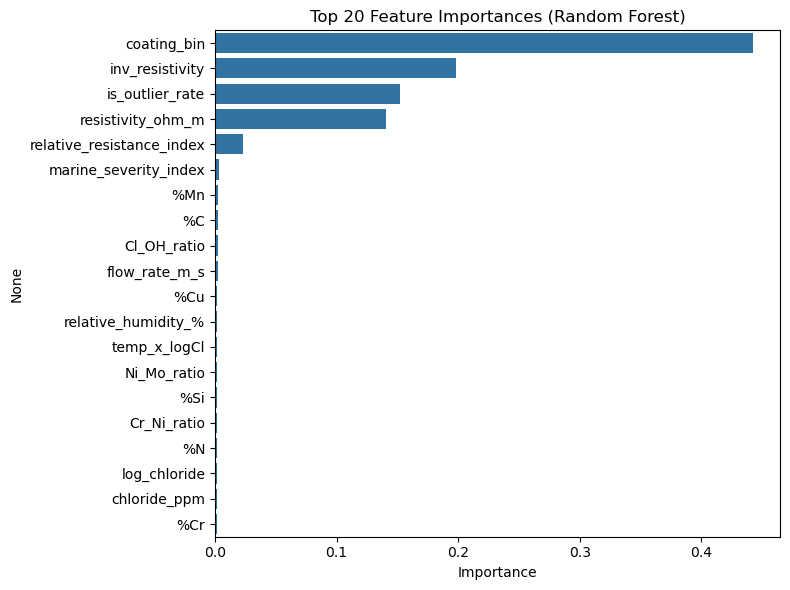

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# 1) Config
DATA_PATH = "/mnt/data/Corrosion_Featured.xlsx"  # change path if needed
TARGET = "corrosion_rate_mm_per_year"
RND = 42


df = pd.read_excel("Corrosion_Featured.xlsx")

X = df.select_dtypes(include=[np.number]).drop(columns=[TARGET], errors='ignore')
y = df[TARGET].values

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RND)

rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=3,
    max_depth=None,
    random_state=RND,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

cv_r2 = cross_val_score(rf, X, y, cv=5, scoring='r2', n_jobs=-1)
cv_mae = -cross_val_score(rf, X, y, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("=== Random Forest Evaluation ===")
print(f"R2 (test): {r2:.4f}")
print(f"MAE (test): {mae:.4f}")
print(f"RMSE (test): {rmse:.4f}")
print(f"CV R2 mean (5-fold): {cv_r2.mean():.4f}  (std: {cv_r2.std():.4f})")
print(f"CV MAE mean (5-fold): {cv_mae.mean():.4f}  (std: {cv_mae.std():.4f})")
print("\nTop 15 features by importance:")
print(feat_imp.head(15))

model_path = "rf_corrosion_model.joblib"
joblib.dump(rf, model_path)
print("\nSaved Random Forest model to:", model_path)
if os.path.exists(model_path):
    print("You can download the model file from the environment or attach it to your submission.")

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect')
plt.xlabel("Actual corrosion_rate_mm_per_year")
plt.ylabel("Predicted corrosion_rate_mm_per_year")
plt.title("Random Forest: Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

top_n = min(20, len(feat_imp))
plt.figure(figsize=(8, max(4, top_n*0.3)))
sns.barplot(x=feat_imp.head(top_n).values, y=feat_imp.head(top_n).index)
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [ ]:
import joblib
import pandas as pd
import numpy as np
import os

# ---------- CONFIG ----------
MODEL_PATH = "rf_corrosion_model.joblib"
TRAINING_FILE = "Corrosion_Featured.xlsx"
# ----------------------------

model = joblib.load(MODEL_PATH)
expected = list(model.feature_names_in_)

# load medians from training file if available
if os.path.exists(TRAINING_FILE):
    df_train = pd.read_excel(TRAINING_FILE)
    medians = df_train.select_dtypes(include=[np.number]).median()
else:
    medians = None

eps = 1e-9

def compute_derived_from_base(base):
    """Compute many common derived features from base input dict."""
    out = dict(base)  # start with given base values

    # PREN
    if all(k in out for k in ["%Cr", "%Mo", "%N"]):
        out["PREN"] = out["%Cr"] + 3.3 * out["%Mo"] + 16 * out["%N"]
    # ratios
    if "%Ni" in out and "%Cr" in out:
        out["Cr_Ni_ratio"] = out["%Cr"] / (out["%Ni"] + eps)
    if "%Mo" in out and "%Cr" in out:
        out["Cr_Mo_ratio"] = out["%Cr"] / (out["%Mo"] + eps)
    if "%Mo" in out and "%Ni" in out:
        out["Ni_Mo_ratio"] = out["%Ni"] / (out["%Mo"] + eps)
    # products
    if "%Cr" in out and "%Ni" in out:
        out["CrxNi"] = out["%Cr"] * out["%Ni"]
    if "%Cr" in out and "%Mo" in out:
        out["CrxMo"] = out["%Cr"] * out["%Mo"]
    # log chloride
    if "chloride_ppm" in out:
        out["log_chloride"] = np.log1p(out["chloride_ppm"])
        out["log_chloride_sq"] = out["log_chloride"] ** 2
    # OH conc and Cl/OH
    if "pH" in out:
        out["OH_conc"] = 10 ** (out["pH"] - 14)
        out["pH_sq"] = out["pH"] ** 2
    if "chloride_ppm" in out and "pH" in out:
        out["Cl_OH_ratio"] = out["chloride_ppm"] / (out["OH_conc"] + eps)
    # temp x logCl
    if "temperature_C" in out and "chloride_ppm" in out:
        out["temp_x_logCl"] = out["temperature_C"] * np.log1p(out["chloride_ppm"])
        out["temperature_C_sq"] = out["temperature_C"] ** 2
    # exposure transforms
    if "exposure_days" in out:
        out["log_exposure_days"] = np.log1p(out["exposure_days"])
        out["sqrt_exposure_days"] = np.sqrt(out["exposure_days"])
    # inv_resistivity
    if "resistivity_ohm_m" in out:
        out["inv_resistivity"] = 1.0 / (out["resistivity_ohm_m"] + eps)
    # squared PREN
    if "PREN" in out:
        out["PREN_sq"] = out["PREN"] ** 2
    # missingness flags (0/1)
    for col in ["%Mo", "pH", "chloride_ppm"]:
        flag = f"{col}_was_missing"
        out[flag] = 0 if (col in base and pd.notna(base[col])) else 1
    # is_outlier_rate default 0 (unless provided)
    if "is_outlier_rate" not in out:
        out["is_outlier_rate"] = 0

    for col in ["material_mean_rate", "material_std_rate", "environment_mean_rate", "environment_std_rate"]:
        if col not in out:
            if medians is not None and col in medians.index:
                out[col] = medians.loc[col]
            else:
                out[col] = 0.0
    return out

def build_feature_vector(base_input):
    # compute derived
    full = compute_derived_from_base(base_input)
    row = {}
    for feat in expected:
        if feat in full and pd.notna(full[feat]):
            row[feat] = full[feat]
        else:
            if medians is not None and feat in medians.index:
                row[feat] = medians.loc[feat]
            else:
                # safe default numeric
                row[feat] = 0.0
    X_pred = pd.DataFrame([row], columns=expected).astype(float)
    return X_pred

def predict_rate(base_input):
    X_pred = build_feature_vector(base_input)
    pred = model.predict(X_pred)[0]
    print(round(float(pred), 4))

base_input = {
    "%Cr": 18.0,
    "%Ni": 8.0,
    "%Mo": 2.0,
    "%C": 0.03,
    "%Mn": 1.5,
    "%Si": 0.4,
    "%Cu": 0.2,
    "%N": 0.05,
    "temperature_C": 35.0,
    "chloride_ppm": 25000.0,
    "pH": 7.5,
    "resistivity_ohm_m": 0.2,
    "flow_rate_m_s": 0.1,
    "relative_humidity_%": 85.0,
    "exposure_days": 90.0,
    "coating_bin": 0
}

predict_rate(base_input)


1.7749
